In [14]:
# Imports
import numpy as np
from ppi_py import ppi_mean_ci
from ppi_py.datasets import load_dataset
from ppi_py import ppi_mean_ci, classical_mean_ci
from tqdm import tqdm
import pandas as pd 
from utils import *
np.random.seed(0) # For reproducibility's sake



In [22]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Load California housing dataset
housing = fetch_california_housing()
X = housing.data
Y = housing.target

# Split data into training and inference sets
X_train, X_inference, Y_train, Y_inference = train_test_split(X, Y, test_size=0.7, random_state=42)

# Train Random Forest model on training set
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

# Generate predictions on the inference set
Yhat_inference = model.predict(X_inference)

# Set up data for PPI
Y_total = Y_inference
Yhat_total = Yhat_inference


In [23]:
alpha = 0.05
n_total = Y_total.shape[0]  # Total number of labeled examples
ns = np.linspace(50, 500, 10).astype(
    int
)  # Test for different numbers of labeled examples
num_trials = 100

# True mean (computed on all labels)
true_theta = Y_total.mean()

In [24]:
results = []
for i in tqdm(range(ns.shape[0])):
    for j in range(num_trials):
        # Prediction-Powered Inference
        n = ns[i]
        rand_idx = np.random.permutation(n_total)
        _Yhat = Yhat_total[rand_idx[:n]]
        _Y = Y_total[rand_idx[:n]]
        _Yhat_unlabeled = Yhat_total[rand_idx[n:]]

        ppi_ci = ppi_mean_ci(_Y, _Yhat, _Yhat_unlabeled, alpha=alpha)

        # Classical interval
        classical_ci = classical_mean_ci(_Y, alpha=alpha)

        # Append results
        results += [
            pd.DataFrame(
                [
                    {
                        "method": "PPI",
                        "n": n,
                        "lower": ppi_ci[0],
                        "upper": ppi_ci[1],
                        "trial": j,
                    }
                ]
            )
        ]
        results += [
            pd.DataFrame(
                [
                    {
                        "method": "Classical",
                        "n": n,
                        "lower": classical_ci[0],
                        "upper": classical_ci[1],
                        "trial": j,
                    }
                ]
            )
        ]

# Imputed CI
imputed_ci = classical_mean_ci(Yhat_total > 0.5, alpha=alpha)
results += [
    pd.DataFrame(
        [
            {
                "method": "Imputation",
                "n": np.nan,
                "lower": imputed_ci[0],
                "upper": imputed_ci[1],
                "trial": 0,
            }
        ]
    )
]

df = pd.concat(results, axis=0, ignore_index=True)
df["width"] = df["upper"] - df["lower"]

100%|██████████| 10/10 [00:05<00:00,  1.78it/s]


In [25]:
df

,method,n,lower,upper,trial,width
0,PPI,50.0,[1.8785318048297404],[2.108103961973983],0,[0.22957215714424262]
1,Classical,50.0,1.532402,2.25268,0,0.720277
2,PPI,50.0,[1.6928061373099612],[1.9529778817085153],1,[0.26017174439855406]
3,Classical,50.0,1.473886,1.884834,1,0.410949
4,PPI,50.0,[1.9465919898477897],[2.281611480636076],2,[0.3350194907882864]
...,...,...,...,...,...,...
1996,PPI,500.0,[1.9949594645076105],[2.0926286022933085],98,[0.09766913778569797]
1997,Classical,500.0,1.916015,2.116582,98,0.200567
1998,PPI,500.0,[2.015645243247194],[2.118983612087593],99,[0.10333836884039904]
1999,Classical,500.0,1.986341,2.193852,99,0.207511


In [26]:
from utils import make_plots

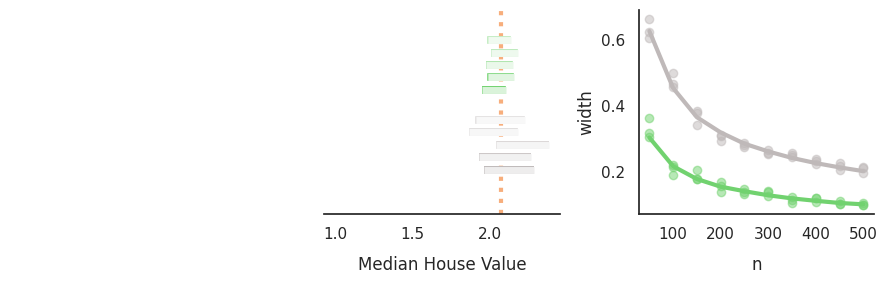

In [27]:
make_plots(
    df,
    "./plots/california_housing.pdf",
    n_idx=3,
    intervals_xlabel="Median House Value",
    true_theta=true_theta,
)